In [ ]:
import os, sys
# Run from project root so all relative paths and imports work
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import yaml
from config import DAS_FILE
from DAS import DAS

with open("configs/denoising.yaml") as f:
    cfg = yaml.safe_load(f)

# Load sensor metadata; yaml values take priority over file metadata
_meta = DAS(DAS_FILE).meta
dx = cfg.get("dx") or _meta["dx"]
dt = cfg.get("dt") or _meta["dt"]

In [ ]:
import json
import os
import numpy as np
import pandas as pd
import torch

from models.unet import UNet
from preprocessing import make_preprocess

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

DATA_DIR = cfg.get("data_dir", "data")
SAVE_DIR = cfg.get("save_dir", "results/denoising")
FS_DAS = cfg["fs"]

df = pd.read_csv(os.path.join(DATA_DIR, cfg["labels_csv"]))
df_pos = df[df["count"] > 0].reset_index(drop=True)

with open(os.path.join(SAVE_DIR, "splits.json")) as f:
    splits = json.load(f)

test_df = df_pos[df_pos["sample_id"].isin(splits["test"])].reset_index(drop=True)
print(f"Test set: {len(test_df)} samples")
display(test_df[["sample_id", "count", "vehicle_type"]])

In [5]:
test_df

,sample_id,data_path,count,start_frame,end_frame,vehicle_type
0,1,data/raw/sample_000001.npy,4,1902,2053,mixed
1,2,data/raw/sample_000002.npy,3,1932,2083,mixed
2,14,data/raw/sample_000014.npy,5,2292,2443,mixed
3,20,data/raw/sample_000020.npy,2,2472,2623,mixed
4,21,data/raw/sample_000021.npy,1,2502,2653,suv
5,23,data/raw/sample_000023.npy,4,2562,2713,mixed
6,29,data/raw/sample_000029.npy,3,2742,2893,mixed
7,32,data/raw/sample_000032.npy,1,2832,2983,van
8,47,data/raw/sample_000047.npy,4,3282,3433,mixed
9,53,data/raw/sample_000053.npy,2,3462,3613,mixed


In [ ]:
steps = [(s["name"], {k: v for k, v in s.items() if k != "name"}) for s in cfg["steps"]]
pp = make_preprocess(steps=steps, dx=dx, dt=dt)
print(f"Pipeline steps: {[s[0] for s in steps]}")

In [7]:
model = UNet(in_channels=1, out_channels=1).to(device)
print(sum(p.numel() for p in model.parameters()), "parameters")

1797409 parameters


In [8]:
# Load the trained model saved by: python train.py --task denoising
model.load_state_dict(torch.load("results/denoising/best_model.pt", map_location=device))
model.eval()
print("Model loaded from results/denoising/best_model.pt")

Model loaded from results/denoising/best_model.pt


/tmp/ipykernel_2651080/3773719988.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("results/denoising/best_model.pt", map_location=device

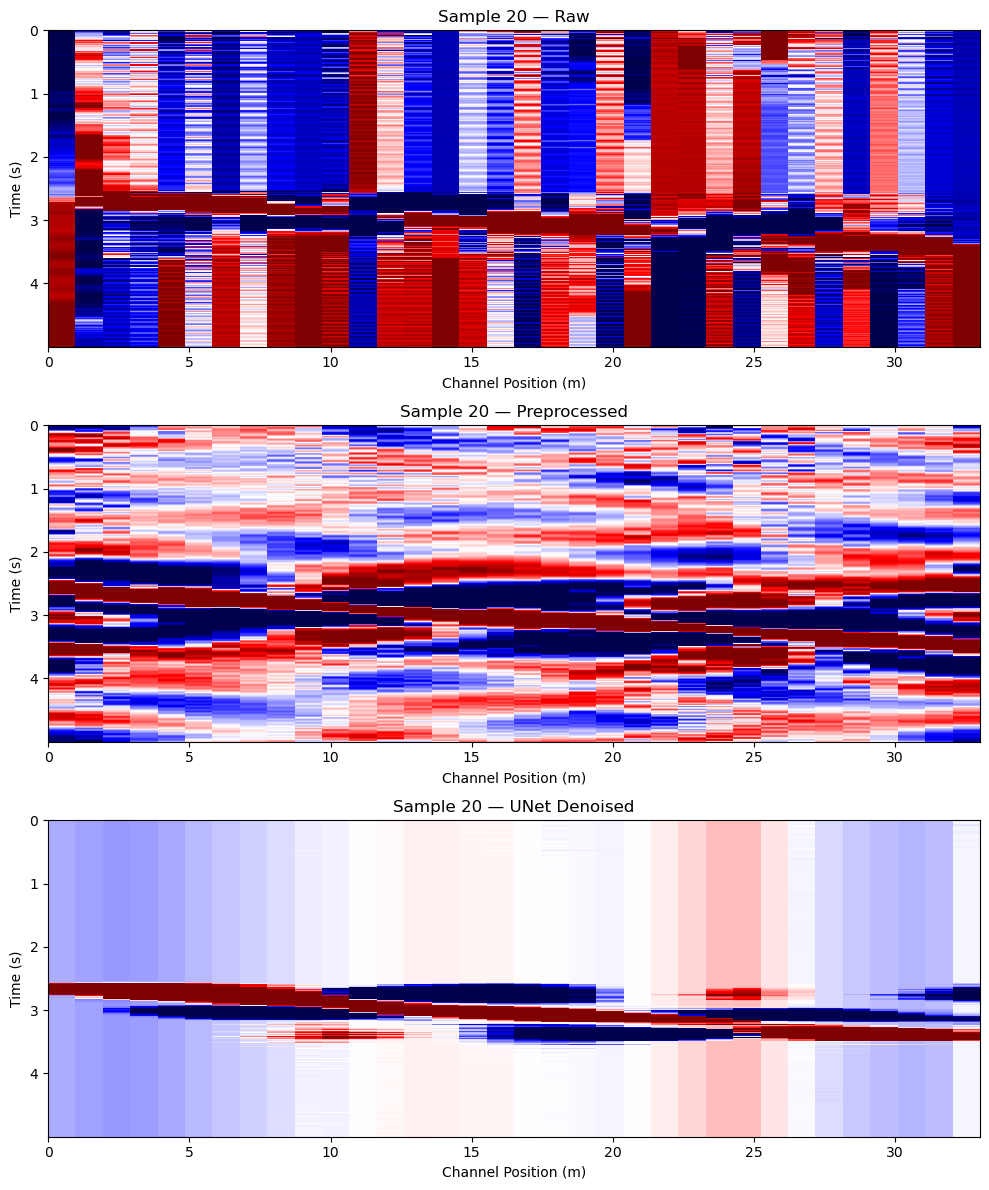

In [12]:
from Utilities import plot_das_data
import matplotlib.pyplot as plt

SAMPLE_IDX = 3  # change to inspect different test samples

row = test_df.iloc[SAMPLE_IDX]
sid = row["sample_id"]
raw = np.load(row["data_path"]).astype(np.float32)
clean = pp(raw, FS_DAS).astype(np.float32)

with torch.no_grad():
    raw_t = torch.from_numpy(raw[None, None, ...]).to(device)
    pred = model(raw_t).squeeze().cpu().numpy()

channels = np.arange(raw.shape[0])
fig, axes = plt.subplots(3, 1, figsize=(10, 12))
plot_das_data(data=raw,   channels=channels, dx=dx, dt=dt, title=f"Sample {sid} — Raw",           ax=axes[0], fig=fig, show=False)
plot_das_data(data=clean, channels=channels, dx=dx, dt=dt, title=f"Sample {sid} — Preprocessed",  ax=axes[1], fig=fig, show=False)
plot_das_data(data=pred,  channels=channels, dx=dx, dt=dt, title=f"Sample {sid} — UNet Denoised", ax=axes[2], fig=fig, show=False)
plt.tight_layout()
plt.show()

In [ ]:
from Utilities import plot_single
import matplotlib.pyplot as plt

CHANNEL = 5  # channel to inspect
T0, T1 = 0, 5

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

plot_single(data=raw,   channel_num=CHANNEL, dx=dx, dt=dt, start_time=T0, end_time=T1, ax=axes[0], show=False)
axes[0].set_title(f"Sample {sid} — Raw | Channel {CHANNEL}")

plot_single(data=clean, channel_num=CHANNEL, dx=dx, dt=dt, start_time=T0, end_time=T1, ax=axes[1], show=False)
axes[1].set_title(f"Sample {sid} — Preprocessed | Channel {CHANNEL}")

plot_single(data=pred,  channel_num=CHANNEL, dx=dx, dt=dt, start_time=T0, end_time=T1, ax=axes[2], show=False)
axes[2].set_title(f"Sample {sid} — UNet Denoised | Channel {CHANNEL}")

plt.tight_layout()
plt.show()

In [ ]:
# Run `python predict.py --task denoising` to regenerate data/denoised/
print("Denoised samples → data/denoised/  |  Run: python predict.py --task denoising")